## Практическая работа 0 - Себежко А.А. П50-1-22

Цель работы: Необходимо провести анализ опроса удовлетворенности использования
веб-сайта пользователями.

Ход работы:

Импортируем библиотеки `pandas` и `numpy`, а также библиотеку для построение графиков `matplotlib`.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Импортируем датасет с данными из опрса.

In [90]:
df = pd.read_csv("survey.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   user_id   106 non-null    object
 1   language  106 non-null    object
 2   platform  95 non-null     object
 3   gender    106 non-null    object
 4   age       106 non-null    int64 
 5   q1        106 non-null    int64 
 6   q2        106 non-null    int64 
 7   q3        106 non-null    int64 
 8   q4        106 non-null    int64 
 9   q5        106 non-null    int64 
 10  q6        106 non-null    int64 
 11  q7        106 non-null    int64 
 12  q8        106 non-null    int64 
 13  q9        106 non-null    int64 
 14  q10       106 non-null    int64 
 15  q11       106 non-null    int64 
 16  q12       106 non-null    int64 
 17  q13       106 non-null    int64 
 18  q14       106 non-null    int64 
 19  q15       106 non-null    int64 
 20  q16       106 non-null    int64 
 21  q17       106 no

1. Проверяем есть ли пустые значения.

In [91]:
df.isnull().sum().sum()
df.isnull().sum()

user_id      0
language     0
platform    11
gender       0
age          0
q1           0
q2           0
q3           0
q4           0
q5           0
q6           0
q7           0
q8           0
q9           0
q10          0
q11          0
q12          0
q13          0
q14          0
q15          0
q16          0
q17          0
q18          0
q19          0
q20          0
q21          0
q22          0
q23          0
q24          0
q25          0
q26          0
dtype: int64

Есть 11 пустых значений в столбце platform. Значит заменим их самым встречаемым значением.

In [92]:
platform_mode = df['platform'].mode()[0]
df['platform'] = df['platform'].fillna(platform_mode)
print(f"Пустых значений {df.isnull().sum().sum()}")

Пустых значений 0


Удаляем дубликаты.

In [93]:
df = df.drop_duplicates()

Получим df только с вопросами.

In [94]:
df_q = df.loc[1:, 'q1': 'q26']
df_q

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,...,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26
1,10,10,10,9,10,10,10,10,9,10,...,10,10,10,10,10,10,10,10,9,8
2,10,10,10,10,10,10,10,10,10,10,...,9,8,10,10,10,10,9,9,8,8
3,5,8,5,5,5,5,5,6,6,8,...,7,9,10,8,8,10,10,8,10,6
4,9,10,9,10,9,7,8,5,7,8,...,7,8,8,8,9,9,10,10,10,10
5,10,9,9,9,5,6,8,7,4,5,...,8,7,7,7,8,6,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6
102,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
103,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
104,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


Видим, что дубликаты были удалены, так как строк стало меньше.

Теперь получим строки в которых все значения одинаковы и удалим их, так мы избавимся от шума.

In [95]:
rows_to_drop = df_q[df_q.nunique(axis=1) == 1].index

df = df.drop(rows_to_drop)
df

,user_id,language,platform,gender,age,q1,q2,q3,q4,q5,...,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26
0,080c468b-27c0-455c-aa63-b8f807f2e3d7,en,Desktop,male,34,9,7,6,6,7,...,8,4,6,5,6,6,5,2,5,3
1,0b0379c7-04db-4c85-84bd-a2bd55329e29,en,Mobile,female,19,10,10,10,9,10,...,10,10,10,10,10,10,10,10,9,8
2,0e623280-b28b-4d4a-8eea-0732f09ed497,en,Mobile,female,19,10,10,10,10,10,...,9,8,10,10,10,10,9,9,8,8
3,045dc0f3-a730-4d03-a615-f51814e5b04f,en,Mobile,male,21,5,8,5,5,5,...,7,9,10,8,8,10,10,8,10,6
4,092f2ee7-5281-4a09-9bce-e5523b95b53b,en,Mobile,female,53,9,10,9,10,9,...,7,8,8,8,9,9,10,10,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,e0ffda50-97e7-4872-a467-cc143cbac8fc,en,Mobile,female,12,10,6,10,6,10,...,10,8,8,9,9,9,10,10,10,8
75,cb71d11a-4e8d-4ab8-80be-ac1f46f5b2d1,en,Mobile,male,1,9,9,9,9,7,...,9,6,7,8,8,9,5,5,7,5
76,cd3dad39-da3f-4ada-9e09-a9832ca7bdd7,en,Mobile,male,21,8,9,10,9,8,...,10,8,10,9,9,8,6,7,8,6
77,f3b94dcb-2dde-48d7-968d-606fcddd692d,en,Desktop,male,46,10,6,10,6,6,...,5,8,6,5,8,6,1,1,1,1


Значений стало еще меньше, значит шум был.

3. Определим средние оценки по каждой категории опроса и определим, какая категория имеет худшую и лучшую оценку. Для начала выведем среднюю оценку по каждой категории.

In [96]:
typography_avg = df.loc[1:, 'q1': 'q3'].mean().mean()
color_avg = df.loc[1:, 'q4': 'q8'].mean().mean()
interactivity_avg = df.loc[1:, 'q9': 'q13'].mean().mean()
navigation_avg = df.loc[1:, 'q14': 'q18'].mean().mean()
satisfaction_avg = df.loc[1:, 'q19': 'q22'].mean().mean()
trust_avg = df.loc[1:, 'q23': 'q24'].mean().mean()
loyalty_avg = df.loc[1:, 'q25': 'q26'].mean().mean()

category_averages = {
    'Типография': typography_avg,
    'Цвет': color_avg,
    'Интерактивность': interactivity_avg,
    'Навигация': navigation_avg,
    'Удовлетворительность': satisfaction_avg,
    'Доверие': trust_avg,
    'Лояльность': loyalty_avg
}

Теперь получим столбец лучшего и худшего и получим их среднюю оценку.

In [97]:
best_category_avg = max(category_averages, key=category_averages.get)
worst_category_avg = min(category_averages, key=category_averages.get)

best_avg = category_averages[best_category_avg]
worst_avg = category_averages[worst_category_avg]


print(
    f"Самый лучший показатель (среднее): {best_category_avg}. Его значение: {best_avg}")
print(
    f"Самый худший показатель (среднее): {worst_category_avg}. Его значение: {worst_avg}")

Самый лучший показатель (среднее): Типография. Его значение: 7.847619047619047
Самый худший показатель (среднее): Интерактивность. Его значение: 6.937142857142857


4. Теперь получим медианные оценки по каждой категории опроса и определим, какая категория имеет худшую и лучшую медианную оценку, т.е. определить слабую и сильную сторону сайта.

In [98]:
typography_median = df.loc[1:, 'q1': 'q3'].median().mean()
color_median = df.loc[1:, 'q4': 'q8'].median().mean()
interactivity_median = df.loc[1:, 'q9': 'q13'].median().mean()
navigation_median = df.loc[1:, 'q14': 'q18'].median().mean()
satisfaction_median = df.loc[1:, 'q19': 'q22'].median().mean()
trust_median = df.loc[1:, 'q23': 'q24'].median().mean()
loyalty_median = df.loc[1:, 'q25': 'q26'].median().mean()

category_medians = {
    'Тимпография': typography_median,
    'Цвета': color_median,
    'Интерактивность': interactivity_median,
    'Навигация': navigation_median,
    'Удовлетворенность': satisfaction_median,
    'Доверие': trust_median,
    'Лояльность': loyalty_median
}

Ну а теперь получим показатели.

In [99]:
best_category_median = max(category_medians, key=category_medians.get)
worst_category_median = min(category_medians, key=category_medians.get)

best_median = category_medians[best_category_median]
worst_median = category_medians[worst_category_median]


print(
    f"Самый лучший показатель (медиана): {best_category_median}. Его значение: {best_median}")
print(
    f"Самый худший показатель (медиана): {worst_category_median}. Его значение: {worst_median}")

Самый лучший показатель (медиана): Тимпография. Его значение: 8.5
Самый худший показатель (медиана): Интерактивность. Его значение: 7.0


5. Построим гистограммы по ответам для каждой категории опроса.

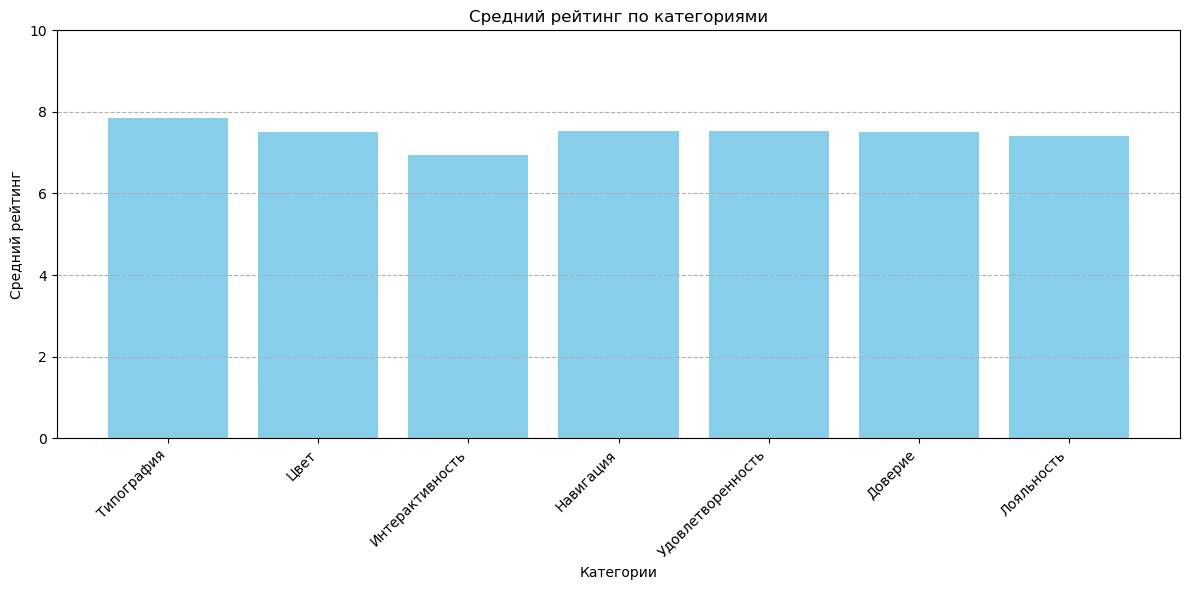

In [100]:
typography_avg = df.loc[1:, 'q1': 'q3'].mean().mean()
color_avg = df.loc[1:, 'q4': 'q8'].mean().mean()
interactivity_avg = df.loc[1:, 'q9': 'q13'].mean().mean()
navigation_avg = df.loc[1:, 'q14': 'q18'].mean().mean()
satisfaction_avg = df.loc[1:, 'q19': 'q22'].mean().mean()
trust_avg = df.loc[1:, 'q23': 'q24'].mean().mean()
loyalty_avg = df.loc[1:, 'q25': 'q26'].mean().mean()

categories = ['Типография', 'Цвет', 'Интерактивность',
              'Навигация', 'Удовлетворенность', 'Доверие', 'Лояльность']
average_values = [typography_avg, color_avg, interactivity_avg,
                  navigation_avg, satisfaction_avg, trust_avg, loyalty_avg]

plt.figure(figsize=(12, 6))

plt.bar(categories, average_values, color='skyblue')
plt.xlabel('Категории') 
plt.ylabel('Средний рейтинг') 
plt.title('Средний рейтинг по категориями')
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Проверим наличие корреляции между доверием и лояльностью у клиентов.

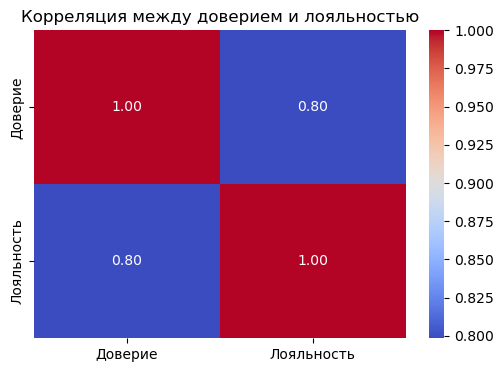

In [101]:
df_heatmap = df.loc[1:, 'q23': 'q26']

df_heatmap['Доверие'] = df_heatmap[['q23', 'q24']].mean(axis=1)
df_heatmap['Лояльность'] = df_heatmap[['q25', 'q26']].mean(axis=1)
df_grouped = df_heatmap[['Доверие', 'Лояльность']]

correlation_matrix = df_grouped.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция между доверием и лояльностью")
plt.show()

Количество пользователей, принявших участие в опросе: 71

Процентное соотношение пользователей по платформам:
platform
Mobile     84.507042
Desktop    15.492958
Name: count, dtype: float64

Процентное соотношение пользователей по полу:
gender
male      60.563380
female    36.619718
other      2.816901
Name: count, dtype: float64

Медианный возраст опрошенных: 20.0



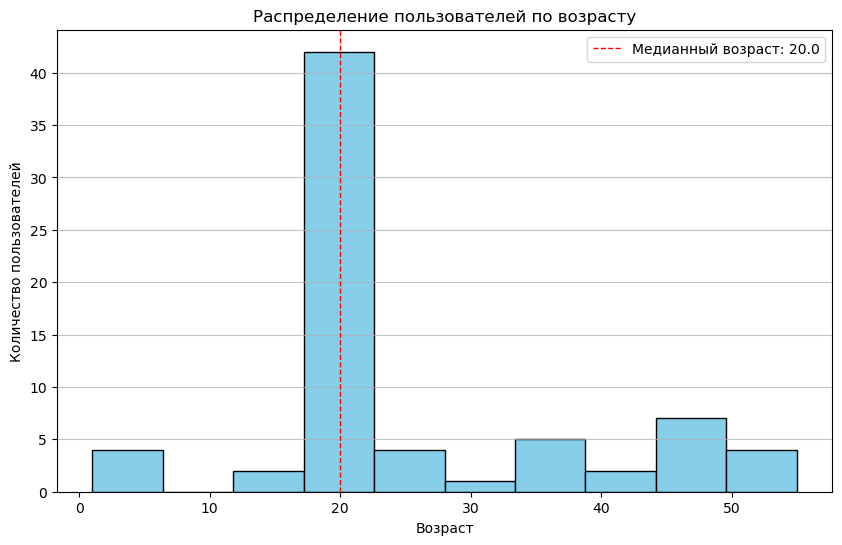


Анализ сильных и слабых сторон сайта
Сильная сторона сайта: Типография (средняя оценка: 8.50)
Слабая сторона сайта: Интерактивность (средняя оценка: 7.00)

Рекомендации по улучшению
Основываясь на результатах опроса:
- Необходимо уделить внимание улучшению пользовательского опыта на платформе с наименьшей представленностью, чтобы повысить вовлеченность пользователей.
- Следует учитывать распределение по полу при разработке контента и маркетинговых кампаний для обеспечения релевантности для всех пользователей.
- Поскольку медианный возраст пользователей составляет 20.0 лет, важно адаптировать контент и функциональность сайта под потребности этой возрастной группы.
- Поддерживайте и развивайте сильные стороны сайта, особенно в категории 'Типография', чтобы сохранить удовлетворенность пользователей.
- Проведите дополнительный анализ слабой стороны сайта ('Интерактивность') для выявления конкретных проблем и разработки решений по их устранению.  Например, проведите тестирование или опросы

In [106]:
# --- Общая информация ---
num_users = len(df)
print(f"Количество пользователей, принявших участие в опросе: {num_users}\n")

# --- Анализ платформы ---
platform_counts = df['platform'].value_counts(
    dropna=True)
platform_percentages = platform_counts / num_users * 100
print("Процентное соотношение пользователей по платформам:")
print(platform_percentages)
print()

# --- Анализ пола ---
gender_counts = df['gender'].value_counts()
gender_percentages = gender_counts / num_users * 100
print("Процентное соотношение пользователей по полу:")
print(gender_percentages)
print()

median_age = df['age'].median()
print(f"Медианный возраст опрошенных: {median_age}\n")

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Возраст")
plt.ylabel("Количество пользователей")
plt.title("Распределение пользователей по возрасту")
plt.axvline(median_age, color='red', linestyle='dashed', linewidth=1,
            label=f'Медианный возраст: {median_age}') 
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

category_averages = {
    'Типография': typography_avg,
    'Цвет': color_avg,
    'Интерактивность': interactivity_avg,
    'Навигация': navigation_avg,
    'Удовлетворенность': satisfaction_avg,
    'Доверие': trust_avg,
    'Лояльность': loyalty_avg
}


print("\nАнализ сильных и слабых сторон сайта")
print(f"Сильная сторона сайта: Типография (средняя оценка: {best_median:.2f})")
print(f"Слабая сторона сайта: Интерактивность (средняя оценка: {worst_median:.2f})")

print("\nРекомендации по улучшению")
print(f"Основываясь на результатах опроса:")

print("- Необходимо уделить внимание улучшению пользовательского опыта на платформе с наименьшей представленностью, чтобы повысить вовлеченность пользователей.")
print("- Следует учитывать распределение по полу при разработке контента и маркетинговых кампаний для обеспечения релевантности для всех пользователей.")
print(f"- Поскольку медианный возраст пользователей составляет {median_age} лет, важно адаптировать контент и функциональность сайта под потребности этой возрастной группы.")
print(f"- Поддерживайте и развивайте сильные стороны сайта, особенно в категории 'Типография', чтобы сохранить удовлетворенность пользователей.")
print(f"- Проведите дополнительный анализ слабой стороны сайта ('Интерактивность') для выявления конкретных проблем и разработки решений по их устранению.  Например, проведите тестирование или опросы, чтобы понять, что именно не устраивает пользователей в этой области.")